# ABI vs MCMC Comparison

This notebook compares the trained ABI amortizer and the exact-model MCMC benchmark on the same exported simulation bank. It is organized section by section so we can inspect parameter recovery, boundary recovery, runtime, and break-even behavior in one place.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.grid": False,
    "grid.alpha": 0.3,
    "grid.linestyle": "-",
    "grid.color": "#b0b0b0",
})

ABI_COLOR = "steelblue"
MCMC_COLOR = "coral"
AGREEMENT_COLOR = "seagreen"
DIFF_COLOR = "mediumpurple"
REFERENCE_COLOR = "black"
TRUE_BOUNDARY_COLOR = "#e45756"
NONBOUNDARY_COLOR = ABI_COLOR
PARAM_DISPLAY_MAP = {
    "beta0": r"$\beta_0$",
    "sigma2_w": r"$\sigma^2_w$",
    "eta": r"$\eta$",
    "rho": r"$\rho$",
}

def apply_sim_more_detailed_theme(ax, grid_axis="both"):
    ax.grid(axis=grid_axis, alpha=0.3)
    return ax

def save_comparison_figure(fig, filename):
    if SAVE_FIGURES:
        PLOTS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        path = PLOTS_OUTPUT_DIR / filename
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"Saved figure to: {path}")


In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "dagar_poisson_boundary_mwg.cpp").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing dagar_poisson_boundary_mwg.cpp")

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_DIR = find_project_root(NOTEBOOK_DIR)
BENCHMARK_DIR = PROJECT_DIR / "datasets" / "benchmark_bank_seed123_n100"
ABI_RESULTS_DIR = BENCHMARK_DIR / "abi_results_all100"
MCMC_RESULTS_DIR = BENCHMARK_DIR / "mcmc_results_all100"
COMPARISON_OUTPUT_DIR = BENCHMARK_DIR / "comparison_abi_vs_mcmc"
PLOTS_OUTPUT_DIR = COMPARISON_OUTPUT_DIR / "plots"

ABI_TRAINING_SEC = None  # set this to the one-time ABI training cost in seconds if you want break-even numbers
SCENARIO_COUNTS = [1, 5, 10, 25, 50, 100, 200, 500, 1000]
EDGE_PLOT_DATASET_ID = None  # set to something like "dataset_0000" to force a specific edge-level plot
EXPORT_TABLES = True
SAVE_FIGURES = True

print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"BENCHMARK_DIR: {BENCHMARK_DIR}")
print(f"ABI_RESULTS_DIR: {ABI_RESULTS_DIR}")
print(f"MCMC_RESULTS_DIR: {MCMC_RESULTS_DIR}")
print(f"PLOTS_OUTPUT_DIR: {PLOTS_OUTPUT_DIR}")


PROJECT_DIR: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC
BENCHMARK_DIR: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC\datasets\benchmark_bank_seed123_n100
ABI_RESULTS_DIR: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC\datasets\benchmark_bank_seed123_n100\abi_results_all100
MCMC_RESULTS_DIR: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC\datasets\benchmark_bank_seed123_n100\mcmc_results_all100
PLOTS_OUTPUT_DIR: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC\datasets\benchmark_bank_seed123_n100\comparison_abi_vs_mcmc\plots


In [3]:
def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    return path


def load_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(require_file(path))


def load_abi_runtime(results_dir: Path) -> pd.DataFrame:
    df = load_csv(results_dir / "combined_runtime.csv").copy()
    required = {"dataset_id", "elapsed_sec", "n_saved_draws"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"ABI runtime file is missing columns: {sorted(missing)}")
    df["abi_elapsed_sec"] = df["elapsed_sec"].astype(float)
    df["abi_n_saved_draws"] = df["n_saved_draws"].astype(int)
    df["abi_sec_per_1000_draws"] = 1000.0 * df["abi_elapsed_sec"] / df["abi_n_saved_draws"].clip(lower=1)
    return df[["dataset_id", "abi_elapsed_sec", "abi_n_saved_draws", "abi_sec_per_1000_draws"]].sort_values("dataset_id").reset_index(drop=True)


def aggregate_mcmc_runtime_from_chains(df: pd.DataFrame) -> pd.DataFrame:
    required = {"dataset_id", "chain", "elapsed_sec", "n_saved_draws"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"MCMC chain runtime file is missing columns: {sorted(missing)}")
    grouped = (
        df.groupby("dataset_id", as_index=False)
        .agg(
            n_chains=("chain", "nunique"),
            n_saved_draws_total=("n_saved_draws", "sum"),
            n_saved_draws_per_chain=("n_saved_draws", "mean"),
            dataset_wall_elapsed_sec=("elapsed_sec", "sum"),
            chain_elapsed_sum_sec=("elapsed_sec", "sum"),
            chain_elapsed_mean_sec=("elapsed_sec", "mean"),
            chain_elapsed_min_sec=("elapsed_sec", "min"),
            chain_elapsed_max_sec=("elapsed_sec", "max"),
        )
    )
    grouped["postprocess_overhead_sec"] = 0.0
    grouped["seconds_per_saved_draw"] = grouped["dataset_wall_elapsed_sec"] / grouped["n_saved_draws_total"].clip(lower=1)
    grouped["seconds_per_1000_saved_draws"] = 1000.0 * grouped["seconds_per_saved_draw"]
    return grouped


def load_mcmc_runtime(results_dir: Path) -> pd.DataFrame:
    summary_path = results_dir / "combined_runtime_summary.csv"
    if summary_path.exists():
        df = load_csv(summary_path).copy()
    else:
        df = aggregate_mcmc_runtime_from_chains(load_csv(results_dir / "combined_runtime.csv"))
    required = {"dataset_id", "dataset_wall_elapsed_sec", "n_saved_draws_total"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"MCMC runtime summary is missing columns: {sorted(missing)}")
    df["mcmc_elapsed_sec"] = df["dataset_wall_elapsed_sec"].astype(float)
    df["mcmc_n_saved_draws"] = df["n_saved_draws_total"].astype(int)
    if "seconds_per_1000_saved_draws" in df.columns:
        df["mcmc_sec_per_1000_draws"] = df["seconds_per_1000_saved_draws"].astype(float)
    else:
        df["mcmc_sec_per_1000_draws"] = 1000.0 * df["mcmc_elapsed_sec"] / df["mcmc_n_saved_draws"].clip(lower=1)
    keep = [
        "dataset_id",
        "mcmc_elapsed_sec",
        "mcmc_n_saved_draws",
        "mcmc_sec_per_1000_draws",
    ]
    extras = [col for col in ["n_chains", "n_saved_draws_per_chain", "chain_elapsed_sum_sec", "chain_elapsed_mean_sec", "chain_elapsed_min_sec", "chain_elapsed_max_sec", "postprocess_overhead_sec"] if col in df.columns]
    return df[keep + extras].sort_values("dataset_id").reset_index(drop=True)


def summarize_runtime(runtime_df: pd.DataFrame, method: str, elapsed_col: str, draws_col: str) -> pd.DataFrame:
    elapsed = runtime_df[elapsed_col].astype(float)
    draws = runtime_df[draws_col].astype(float)
    return pd.DataFrame([{
        "method": method,
        "n_datasets": int(runtime_df["dataset_id"].nunique()),
        "mean_elapsed_sec": float(elapsed.mean()),
        "median_elapsed_sec": float(elapsed.median()),
        "sd_elapsed_sec": float(elapsed.std(ddof=1)) if len(elapsed) > 1 else 0.0,
        "min_elapsed_sec": float(elapsed.min()),
        "max_elapsed_sec": float(elapsed.max()),
        "total_elapsed_sec": float(elapsed.sum()),
        "mean_saved_draws": float(draws.mean()),
        "median_saved_draws": float(draws.median()),
        "mean_sec_per_1000_draws": float((1000.0 * elapsed / draws.clip(lower=1)).mean()),
    }])


def interval_overlap_fraction(lower_a, upper_a, lower_b, upper_b) -> float:
    overlap = max(0.0, min(upper_a, upper_b) - max(lower_a, lower_b))
    union = max(upper_a, upper_b) - min(lower_a, lower_b)
    if union <= 0:
        return 1.0
    return overlap / union


def safe_corr(x: pd.Series, y: pd.Series) -> float:
    if len(x) < 2:
        return float("nan")
    if x.nunique(dropna=True) < 2 or y.nunique(dropna=True) < 2:
        return float("nan")
    return float(x.corr(y))


def summarize_parameter_method(df: pd.DataFrame) -> pd.DataFrame:
    grouped = (
        df.groupby(["method", "parameter"], as_index=False)
        .agg(
            n_datasets=("dataset_id", "nunique"),
            mean_bias=("bias_mean", "mean"),
            mean_abs_error=("abs_error_mean", "mean"),
            median_abs_error=("abs_error_mean", "median"),
            mean_coverage_95=("covered_95", "mean"),
            mean_posterior_sd=("posterior_sd", "mean"),
            mean_posterior_mean=("posterior_mean", "mean"),
            mean_truth=("truth", "mean"),
        )
    )
    grouped["mean_coverage_95"] = grouped["mean_coverage_95"].astype(float)
    return grouped.sort_values(["parameter", "method"]).reset_index(drop=True)


def summarize_parameter_agreement(abi_df: pd.DataFrame, mcmc_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    merged = abi_df.merge(
        mcmc_df,
        on=["dataset_id", "parameter"],
        suffixes=("_abi", "_mcmc"),
        how="inner",
    )
    merged["posterior_mean_diff"] = merged["posterior_mean_abi"] - merged["posterior_mean_mcmc"]
    merged["posterior_median_diff"] = merged["posterior_median_abi"] - merged["posterior_median_mcmc"]
    merged["abs_posterior_mean_diff"] = merged["posterior_mean_diff"].abs()
    merged["abs_posterior_median_diff"] = merged["posterior_median_diff"].abs()
    merged["interval_overlap_fraction"] = [
        interval_overlap_fraction(a, b, c, d)
        for a, b, c, d in zip(merged["lower_95_abi"], merged["upper_95_abi"], merged["lower_95_mcmc"], merged["upper_95_mcmc"])
    ]

    summary = (
        merged.groupby("parameter", as_index=False)
        .agg(
            n_datasets=("dataset_id", "nunique"),
            mean_abs_posterior_mean_diff=("abs_posterior_mean_diff", "mean"),
            median_abs_posterior_mean_diff=("abs_posterior_mean_diff", "median"),
            mean_abs_posterior_median_diff=("abs_posterior_median_diff", "mean"),
            mean_interval_overlap_fraction=("interval_overlap_fraction", "mean"),
            posterior_mean_corr=("posterior_mean_abi", lambda s: safe_corr(s, merged.loc[s.index, "posterior_mean_mcmc"])),
        )
    )
    return merged.sort_values(["parameter", "dataset_id"]).reset_index(drop=True), summary.sort_values("parameter").reset_index(drop=True)


def summarize_edge_metrics(df: pd.DataFrame) -> pd.DataFrame:
    metric_cols = [
        "auroc",
        "average_precision",
        "brier",
        "sensitivity_mpm",
        "specificity_mpm",
        "posterior_boundary_count_mpm",
        "true_boundary_count",
        "boundary_count_mean_draws",
        "boundary_count_truth_in_95",
    ]
    grouped = (
        df.groupby("method", as_index=False)[metric_cols]
        .agg(["mean", "median"])
    )
    grouped.columns = ["_".join([c for c in col if c]).rstrip("_") for col in grouped.columns.to_flat_index()]
    grouped = grouped.rename(columns={"method": "method"})
    return grouped


def load_edge_probability_pairs(abi_results_dir: Path, mcmc_results_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    abi_per_dir = abi_results_dir / "per_dataset"
    mcmc_per_dir = mcmc_results_dir / "per_dataset"
    if not abi_per_dir.exists() or not mcmc_per_dir.exists():
        raise FileNotFoundError("Both results directories must contain per_dataset/ folders.")

    dataset_ids = sorted(set(p.name for p in abi_per_dir.iterdir() if p.is_dir()) & set(p.name for p in mcmc_per_dir.iterdir() if p.is_dir()))
    if not dataset_ids:
        raise ValueError("No common per-dataset result folders were found between ABI and MCMC.")

    pair_rows = []
    summary_rows = []
    for dataset_id in dataset_ids:
        abi_path = abi_per_dir / dataset_id / f"{dataset_id}_edge_probabilities.csv"
        mcmc_path = mcmc_per_dir / dataset_id / f"{dataset_id}_edge_probabilities.csv"
        if not abi_path.exists() or not mcmc_path.exists():
            continue

        abi_df = pd.read_csv(abi_path)
        mcmc_df = pd.read_csv(mcmc_path)
        merged = abi_df.merge(
            mcmc_df[["edge_index_1based", "boundary_prob_mcmc", "boundary_median_mcmc"]],
            on="edge_index_1based",
            how="inner",
        )
        if merged.empty:
            continue
        merged["dataset_id"] = dataset_id
        merged["abs_prob_diff"] = (merged["boundary_prob_abi"] - merged["boundary_prob_mcmc"]).abs()
        pair_rows.append(merged)

        abi_sel = int(merged["boundary_median_abi"].sum())
        mcmc_sel = int(merged["boundary_median_mcmc"].sum())
        shared = int(((merged["boundary_median_abi"] == 1) & (merged["boundary_median_mcmc"] == 1)).sum())
        union = int(((merged["boundary_median_abi"] == 1) | (merged["boundary_median_mcmc"] == 1)).sum())
        summary_rows.append({
            "dataset_id": dataset_id,
            "edge_count": int(len(merged)),
            "truth_boundary_count": int(merged["boundary_true"].sum()) if "boundary_true" in merged.columns else np.nan,
            "boundary_prob_corr": safe_corr(merged["boundary_prob_abi"], merged["boundary_prob_mcmc"]),
            "boundary_prob_mae": float(merged["abs_prob_diff"].mean()),
            "abi_selected": abi_sel,
            "mcmc_selected": mcmc_sel,
            "shared_selected": shared,
            "jaccard_selected": float(shared / union) if union > 0 else np.nan,
            "abi_in_mcmc_pct": float(100.0 * shared / abi_sel) if abi_sel > 0 else np.nan,
            "mcmc_in_abi_pct": float(100.0 * shared / mcmc_sel) if mcmc_sel > 0 else np.nan,
        })

    if not pair_rows:
        raise ValueError("No common edge probability files were merged successfully.")

    pairs = pd.concat(pair_rows, ignore_index=True)
    summary = pd.DataFrame(summary_rows).sort_values("dataset_id").reset_index(drop=True)
    return pairs, summary


def summarize_edge_agreement(summary_df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = [
        "boundary_prob_corr",
        "boundary_prob_mae",
        "abi_selected",
        "mcmc_selected",
        "shared_selected",
        "jaccard_selected",
        "abi_in_mcmc_pct",
        "mcmc_in_abi_pct",
    ]
    rows = []
    for col in numeric_cols:
        rows.append({
            "metric": col,
            "mean": float(summary_df[col].mean()),
            "median": float(summary_df[col].median()),
            "sd": float(summary_df[col].std(ddof=1)) if len(summary_df) > 1 else 0.0,
            "min": float(summary_df[col].min()),
            "max": float(summary_df[col].max()),
        })
    return pd.DataFrame(rows)


def build_break_even(runtime_comparison: pd.DataFrame, abi_training_sec: float | None) -> tuple[pd.DataFrame, pd.DataFrame]:
    mean_mcmc = float(runtime_comparison["mcmc_elapsed_sec"].mean())
    median_mcmc = float(runtime_comparison["mcmc_elapsed_sec"].median())
    mean_abi = float(runtime_comparison["abi_elapsed_sec"].mean())
    median_abi = float(runtime_comparison["abi_elapsed_sec"].median())

    rows = []
    for basis, mcmc_sec, abi_sec in [("mean", mean_mcmc, mean_abi), ("median", median_mcmc, median_abi)]:
        per_dataset_saved = mcmc_sec - abi_sec
        row = {
            "basis": basis,
            "mcmc_elapsed_sec": mcmc_sec,
            "abi_elapsed_sec": abi_sec,
            "per_dataset_time_saved_sec": per_dataset_saved,
            "abi_training_sec": float(abi_training_sec) if abi_training_sec is not None else np.nan,
        }
        if abi_training_sec is None:
            row["break_even_datasets"] = np.nan
            row["break_even_datasets_ceiling"] = np.nan
        elif per_dataset_saved <= 0:
            row["break_even_datasets"] = np.inf
            row["break_even_datasets_ceiling"] = np.inf
        else:
            n_star = abi_training_sec / per_dataset_saved
            row["break_even_datasets"] = float(n_star)
            row["break_even_datasets_ceiling"] = int(math.ceil(n_star))
        rows.append(row)

    scenarios = []
    train_cost = 0.0 if abi_training_sec is None else float(abi_training_sec)
    for n_datasets in SCENARIO_COUNTS:
        total_mcmc = n_datasets * mean_mcmc
        total_abi_deploy = n_datasets * mean_abi
        total_abi_with_training = train_cost + total_abi_deploy
        scenarios.append({
            "n_datasets": int(n_datasets),
            "mcmc_total_sec": float(total_mcmc),
            "abi_deploy_total_sec": float(total_abi_deploy),
            "abi_training_sec": float(train_cost),
            "abi_total_with_training_sec": float(total_abi_with_training),
            "abi_minus_mcmc_sec": float(total_abi_with_training - total_mcmc),
            "abi_faster_with_training": bool(total_abi_with_training < total_mcmc),
        })

    return pd.DataFrame(rows), pd.DataFrame(scenarios)


## 1. Load ABI and MCMC benchmark outputs

In [4]:
abi_param = load_csv(ABI_RESULTS_DIR / "combined_parameter_summaries.csv")
mcmc_param = load_csv(MCMC_RESULTS_DIR / "combined_parameter_summaries.csv")
abi_edge_metrics = load_csv(ABI_RESULTS_DIR / "combined_edge_metrics.csv")
mcmc_edge_metrics = load_csv(MCMC_RESULTS_DIR / "combined_edge_metrics.csv")
abi_runtime = load_abi_runtime(ABI_RESULTS_DIR)
mcmc_runtime = load_mcmc_runtime(MCMC_RESULTS_DIR)

abi_param["method"] = "ABI"
mcmc_param["method"] = "MCMC"
abi_edge_metrics["method"] = "ABI"
mcmc_edge_metrics["method"] = "MCMC"

param_all = pd.concat([abi_param, mcmc_param], ignore_index=True)
edge_metrics_all = pd.concat([abi_edge_metrics, mcmc_edge_metrics], ignore_index=True)

common_dataset_ids = sorted(set(abi_param["dataset_id"]) & set(mcmc_param["dataset_id"]))
print(f"ABI datasets: {abi_param['dataset_id'].nunique()}")
print(f"MCMC datasets: {mcmc_param['dataset_id'].nunique()}")
print(f"Common datasets: {len(common_dataset_ids)}")

display(param_all.head())
display(edge_metrics_all.head())


ABI datasets: 100
MCMC datasets: 100
Common datasets: 100


,dataset_id,parameter,posterior_mean,posterior_sd,posterior_median,lower_95,upper_95,truth,bias_mean,abs_error_mean,covered_95,method
0,dataset_0000,beta0,-0.709619,0.072406,-0.711638,-0.807672,-0.617500,-0.685540,-0.024079,0.024079,1,ABI
1,dataset_0000,sigma2_w,0.391629,0.174728,0.348860,0.187546,0.867136,0.181137,0.210493,0.210493,0,ABI
2,dataset_0000,eta_raw,0.319897,0.243645,0.258186,0.014033,0.933616,0.569412,-0.249516,0.249516,1,ABI
3,dataset_0000,eta,0.207372,0.157942,0.167368,0.009097,0.605212,0.369119,-0.161747,0.161747,1,ABI
4,dataset_0000,rho,0.289253,0.181949,0.257162,0.023077,0.706689,0.186174,0.103079,0.103079,1,ABI


,dataset_id,edge_count,true_boundary_count,posterior_boundary_count_mpm,auroc,average_precision,brier,sensitivity_mpm,specificity_mpm,boundary_count_mean_draws,boundary_count_lower_95,boundary_count_upper_95,boundary_count_truth_in_95,method
0,dataset_0000,161,33,0,1.0,1.0,0.111054,0.000000,1.000000,12.8478,0.0,75.000,1,ABI
1,dataset_0001,242,121,76,1.0,1.0,0.136002,0.628099,1.000000,71.0112,0.0,117.000,0,ABI
2,dataset_0002,490,8,4,1.0,1.0,0.017620,0.500000,1.000000,30.4936,0.0,157.000,1,ABI
3,dataset_0003,381,158,163,1.0,1.0,0.016915,1.000000,0.977578,160.9913,103.0,189.000,1,ABI
4,dataset_0004,638,148,39,1.0,1.0,0.105438,0.263514,1.000000,55.3416,0.0,194.025,1,ABI


## 2. Runtime comparison and break-even

In [5]:
runtime_comparison = mcmc_runtime.merge(abi_runtime, on="dataset_id", how="inner")
runtime_comparison["elapsed_diff_sec"] = runtime_comparison["mcmc_elapsed_sec"] - runtime_comparison["abi_elapsed_sec"]
runtime_comparison["speedup_mcmc_over_abi"] = runtime_comparison["mcmc_elapsed_sec"] / runtime_comparison["abi_elapsed_sec"].clip(lower=1e-12)
runtime_comparison["draw_ratio_mcmc_over_abi"] = runtime_comparison["mcmc_n_saved_draws"] / runtime_comparison["abi_n_saved_draws"].clip(lower=1)
runtime_comparison["mcmc_minus_abi_sec_per_1000_draws"] = runtime_comparison["mcmc_sec_per_1000_draws"] - runtime_comparison["abi_sec_per_1000_draws"]

runtime_summary = pd.concat([
    summarize_runtime(runtime_comparison, "ABI", "abi_elapsed_sec", "abi_n_saved_draws"),
    summarize_runtime(runtime_comparison, "MCMC", "mcmc_elapsed_sec", "mcmc_n_saved_draws"),
], ignore_index=True)

break_even_summary, break_even_scenarios = build_break_even(runtime_comparison, ABI_TRAINING_SEC)

display(runtime_summary)
display(runtime_comparison.head())
display(break_even_summary)
display(break_even_scenarios)


,method,n_datasets,mean_elapsed_sec,median_elapsed_sec,sd_elapsed_sec,min_elapsed_sec,max_elapsed_sec,total_elapsed_sec,mean_saved_draws,median_saved_draws,mean_sec_per_1000_draws
0,ABI,100,0.779142,0.762592,0.055363,0.715523,1.027553,77.914194,10000.0,10000.0,0.077914
1,MCMC,100,2.839500,2.830000,1.400826,0.690000,5.530000,283.950000,10000.0,10000.0,0.283950


,dataset_id,mcmc_elapsed_sec,mcmc_n_saved_draws,mcmc_sec_per_1000_draws,n_chains,n_saved_draws_per_chain,chain_elapsed_sum_sec,chain_elapsed_mean_sec,chain_elapsed_min_sec,chain_elapsed_max_sec,postprocess_overhead_sec,abi_elapsed_sec,abi_n_saved_draws,abi_sec_per_1000_draws,elapsed_diff_sec,speedup_mcmc_over_abi,draw_ratio_mcmc_over_abi,mcmc_minus_abi_sec_per_1000_draws
0,dataset_0000,0.85,10000,0.085,1,10000,0.85,0.85,0.85,0.85,0.0,0.773797,10000,0.077380,0.076203,1.098480,1.0,0.007620
1,dataset_0001,1.12,10000,0.112,1,10000,1.12,1.12,1.12,1.12,0.0,0.768197,10000,0.076820,0.351803,1.457959,1.0,0.035180
2,dataset_0002,2.84,10000,0.284,1,10000,2.84,2.84,2.84,2.84,0.0,0.766981,10000,0.076698,2.073019,3.702830,1.0,0.207302
3,dataset_0003,1.98,10000,0.198,1,10000,1.98,1.98,1.98,1.98,0.0,0.761138,10000,0.076114,1.218862,2.601368,1.0,0.121886
4,dataset_0004,3.75,10000,0.375,1,10000,3.75,3.75,3.75,3.75,0.0,0.762078,10000,0.076208,2.987922,4.920757,1.0,0.298792


,basis,mcmc_elapsed_sec,abi_elapsed_sec,per_dataset_time_saved_sec,abi_training_sec,break_even_datasets,break_even_datasets_ceiling
0,mean,2.8395,0.779142,2.060358,NaN,NaN,NaN
1,median,2.8300,0.762592,2.067408,NaN,NaN,NaN


,n_datasets,mcmc_total_sec,abi_deploy_total_sec,abi_training_sec,abi_total_with_training_sec,abi_minus_mcmc_sec,abi_faster_with_training
0,1,2.8395,0.779142,0.0,0.779142,-2.060358,True
1,5,14.1975,3.895710,0.0,3.895710,-10.301790,True
2,10,28.3950,7.791419,0.0,7.791419,-20.603581,True
3,25,70.9875,19.478549,0.0,19.478549,-51.508951,True
4,50,141.9750,38.957097,0.0,38.957097,-103.017903,True
5,100,283.9500,77.914194,0.0,77.914194,-206.035806,True
6,200,567.9000,155.828388,0.0,155.828388,-412.071612,True
7,500,1419.7500,389.570971,0.0,389.570971,-1030.179029,True
8,1000,2839.5000,779.141942,0.0,779.141942,-2060.358058,True


Saved figure to: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC\datasets\benchmark_bank_seed123_n100\comparison_abi_vs_mcmc\plots\runtime_comparison.png


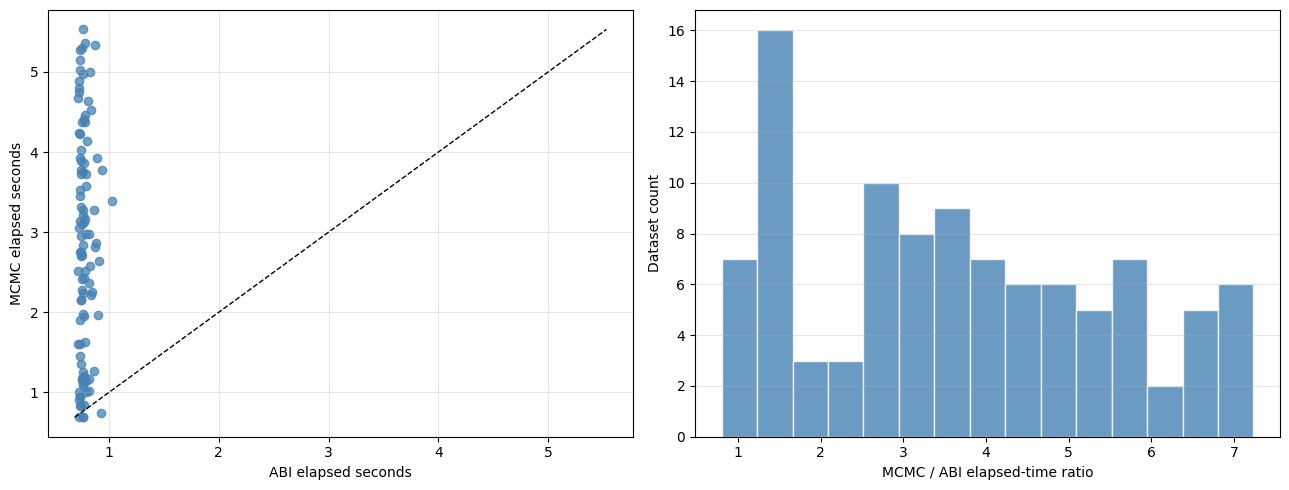

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(runtime_comparison["abi_elapsed_sec"], runtime_comparison["mcmc_elapsed_sec"], alpha=0.75, color=ABI_COLOR)
lo = min(runtime_comparison["abi_elapsed_sec"].min(), runtime_comparison["mcmc_elapsed_sec"].min())
hi = max(runtime_comparison["abi_elapsed_sec"].max(), runtime_comparison["mcmc_elapsed_sec"].max())
ax.plot([lo, hi], [lo, hi], linestyle="--", color=REFERENCE_COLOR, linewidth=1)
ax.set_xlabel("ABI elapsed seconds")
ax.set_ylabel("MCMC elapsed seconds")
apply_sim_more_detailed_theme(ax)

ax = axes[1]
ax.hist(runtime_comparison["speedup_mcmc_over_abi"], bins=15, color=ABI_COLOR, alpha=0.8, edgecolor="white")
ax.set_xlabel("MCMC / ABI elapsed-time ratio")
ax.set_ylabel("Dataset count")
apply_sim_more_detailed_theme(ax, grid_axis="y")

plt.tight_layout()
save_comparison_figure(fig, "runtime_comparison.png")
plt.show()


## 3. Parameter recovery against truth

In [7]:
parameter_method_summary = summarize_parameter_method(param_all)
parameter_pairwise, parameter_agreement_summary = summarize_parameter_agreement(abi_param, mcmc_param)

display(parameter_method_summary)
display(parameter_agreement_summary)
display(parameter_pairwise.head())


,method,parameter,n_datasets,mean_bias,mean_abs_error,median_abs_error,mean_coverage_95,mean_posterior_sd,mean_posterior_mean,mean_truth
0,ABI,beta0,100,-0.003675,0.018558,0.011735,0.90,0.034647,-0.049672,-0.045997
1,MCMC,beta0,100,-0.001911,0.012612,0.009899,0.94,0.012987,-0.047908,-0.045997
2,ABI,eta,100,-0.020210,0.114517,0.100018,0.95,0.143061,0.357311,0.377521
3,MCMC,eta,100,-0.024101,0.079638,0.057611,0.95,0.097598,0.353420,0.377521
4,ABI,eta_raw,100,-0.030811,0.158108,0.138039,0.95,0.198858,0.498997,0.529808
5,MCMC,eta_raw,100,-0.034623,0.109963,0.082416,0.95,0.135306,0.495185,0.529808
6,ABI,rho,100,-0.024906,0.098613,0.080756,0.96,0.132964,0.520280,0.545186
7,MCMC,rho,100,-0.052417,0.093619,0.068144,0.90,0.092807,0.492769,0.545186
8,ABI,sigma2_w,100,0.005529,0.109694,0.085163,0.96,0.153323,0.387832,0.382303
9,MCMC,sigma2_w,100,-0.000976,0.122652,0.045612,0.88,0.177524,0.381327,0.382303


,parameter,n_datasets,mean_abs_posterior_mean_diff,median_abs_posterior_mean_diff,mean_abs_posterior_median_diff,mean_interval_overlap_fraction,posterior_mean_corr
0,beta0,100,0.010265,0.006536,0.010415,0.602664,0.999722
1,eta,100,0.065940,0.049429,0.072698,0.640260,0.845808
2,eta_raw,100,0.090892,0.069775,0.100609,0.640260,0.856343
3,rho,100,0.067611,0.037112,0.075298,0.689083,0.926886
4,sigma2_w,100,0.095949,0.054619,0.060791,0.530891,0.899138


,dataset_id,parameter,posterior_mean_abi,posterior_sd_abi,posterior_median_abi,lower_95_abi,upper_95_abi,truth_abi,bias_mean_abi,abs_error_mean_abi,covered_95_abi,method_abi,posterior_mean_mcmc,posterior_sd_mcmc,posterior_median_mcmc,lower_95_mcmc,upper_95_mcmc,truth_mcmc,bias_mean_mcmc,abs_error_mean_mcmc,covered_95_mcmc,method_mcmc,posterior_mean_diff,posterior_median_diff,abs_posterior_mean_diff,abs_posterior_median_diff,interval_overlap_fraction
0,dataset_0000,beta0,-0.709619,0.072406,-0.711638,-0.807672,-0.617500,-0.685540,-0.024079,0.024079,1,ABI,-0.682775,0.032389,-0.681461,-0.748206,-0.623045,-0.685540,0.002765,0.002765,1,MCMC,-0.026844,-0.030178,0.026844,0.030178,0.658147
1,dataset_0001,beta0,-0.011737,0.023705,-0.011422,-0.040673,0.016795,0.027281,-0.039018,0.039018,0,ABI,-0.007620,0.011173,-0.007420,-0.030508,0.014612,0.027281,-0.034901,0.034901,0,MCMC,-0.004117,-0.004002,0.004117,0.004002,0.785138
2,dataset_0002,beta0,0.750077,0.043532,0.752204,0.708607,0.792282,0.708071,0.042007,0.042007,0,ABI,0.733360,0.013209,0.733918,0.705826,0.758243,0.708071,0.025289,0.025289,1,MCMC,0.016717,0.018286,0.016717,0.018286,0.574126
3,dataset_0003,beta0,0.197321,0.021542,0.197603,0.162713,0.231937,0.191160,0.006161,0.006161,1,ABI,0.193632,0.015279,0.193410,0.164472,0.223343,0.191160,0.002472,0.002472,1,MCMC,0.003689,0.004194,0.003689,0.004194,0.850421
4,dataset_0004,beta0,0.388582,0.019124,0.388550,0.365863,0.412956,0.383591,0.004991,0.004991,1,ABI,0.384347,0.005630,0.384291,0.373353,0.395670,0.383591,0.000756,0.000756,1,MCMC,0.004235,0.004259,0.004235,0.004259,0.473887


Saved figure to: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC\datasets\benchmark_bank_seed123_n100\comparison_abi_vs_mcmc\plots\parameter_recovery_bars.png


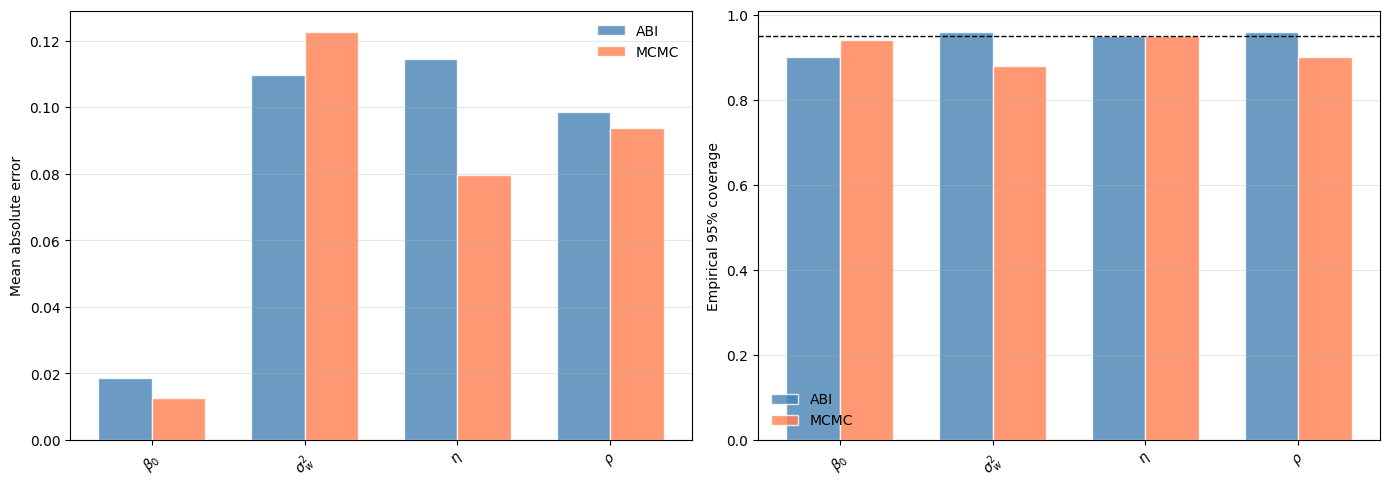

In [8]:
param_order = ["beta0", "sigma2_w", "eta", "rho"]
plot_df = parameter_method_summary.loc[
    parameter_method_summary["parameter"].isin(param_order),
    ["method", "parameter", "mean_abs_error", "mean_coverage_95"],
].copy()
plot_df["parameter"] = pd.Categorical(plot_df["parameter"], categories=param_order, ordered=True)
plot_df = plot_df.sort_values(["parameter", "method"])

mae_pivot = plot_df.pivot(index="parameter", columns="method", values="mean_abs_error").reindex(param_order)
cov_pivot = plot_df.pivot(index="parameter", columns="method", values="mean_coverage_95").reindex(param_order)
param_ticklabels = [PARAM_DISPLAY_MAP[p] for p in param_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

width = 0.35
x = np.arange(len(param_order))
abi_vals = mae_pivot["ABI"].to_numpy()
mcmc_vals = mae_pivot["MCMC"].to_numpy()
axes[0].bar(x - width/2, abi_vals, width=width, label="ABI", color=ABI_COLOR, alpha=0.8, edgecolor="white")
axes[0].bar(x + width/2, mcmc_vals, width=width, label="MCMC", color=MCMC_COLOR, alpha=0.8, edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(param_ticklabels, rotation=45)
axes[0].set_ylabel("Mean absolute error")
axes[0].legend(frameon=False)
apply_sim_more_detailed_theme(axes[0], grid_axis="y")

abi_cov = cov_pivot["ABI"].to_numpy()
mcmc_cov = cov_pivot["MCMC"].to_numpy()
axes[1].bar(x - width/2, abi_cov, width=width, label="ABI", color=ABI_COLOR, alpha=0.8, edgecolor="white")
axes[1].bar(x + width/2, mcmc_cov, width=width, label="MCMC", color=MCMC_COLOR, alpha=0.8, edgecolor="white")
axes[1].axhline(0.95, linestyle="--", color=REFERENCE_COLOR, linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(param_ticklabels, rotation=45)
axes[1].set_ylabel("Empirical 95% coverage")
axes[1].legend(frameon=False)
apply_sim_more_detailed_theme(axes[1], grid_axis="y")

plt.tight_layout()
save_comparison_figure(fig, "parameter_recovery_bars.png")
plt.show()


### Additional parameter-recovery plots

These panels complement the aggregate error and coverage summaries by showing how each method tracks the true generating parameters dataset by dataset, how closely ABI and MCMC agree directly, and how the signed errors and interval widths are distributed across datasets.


Saved figure to: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC\datasets\benchmark_bank_seed123_n100\comparison_abi_vs_mcmc\plots\parameter_recovery_truth_scatter.png


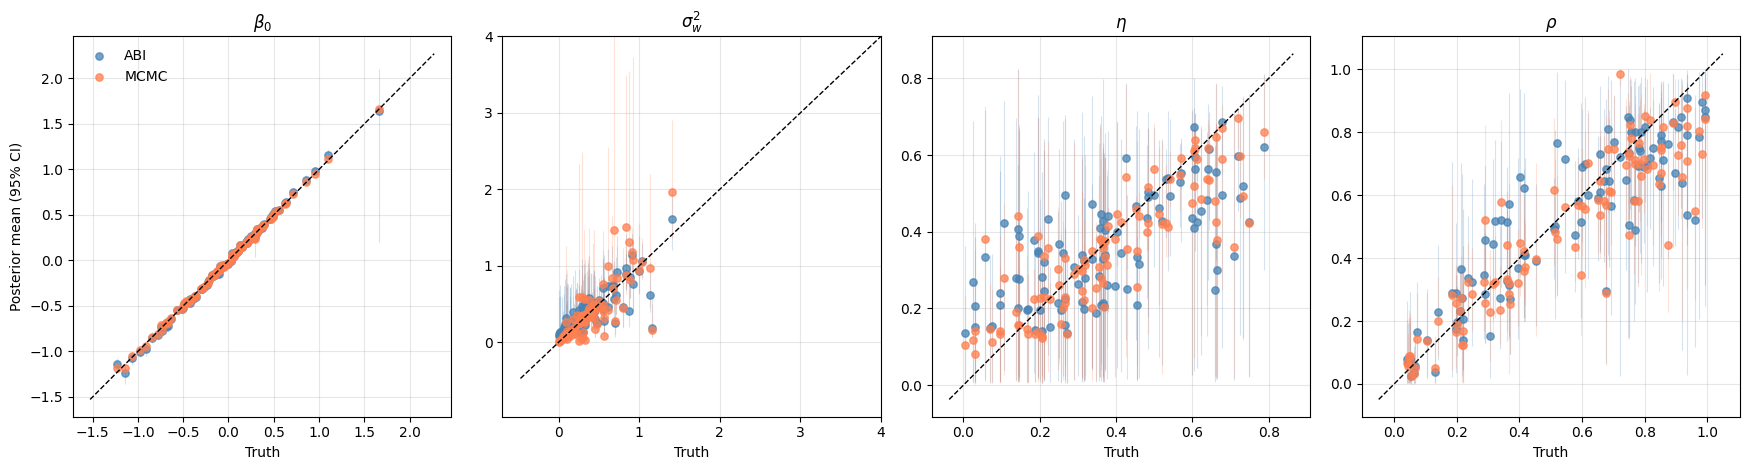

Saved figure to: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC\datasets\benchmark_bank_seed123_n100\comparison_abi_vs_mcmc\plots\parameter_recovery_agreement_scatter.png


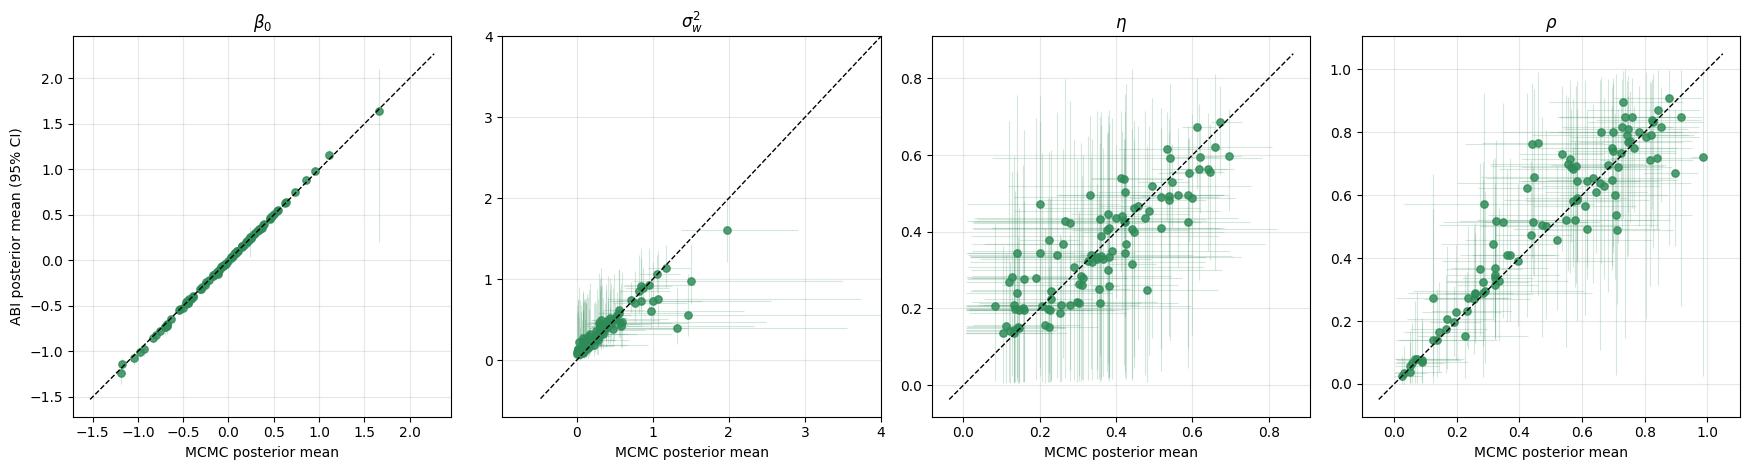

In [9]:
param_scatter_df = parameter_pairwise.copy()
param_scatter_df["truth"] = param_scatter_df["truth_abi"]

PARAM_AXIS_UPPER_LIMITS = {"sigma2_w": 4.0}

# Truth vs posterior mean with 95% credible intervals
fig, axes = plt.subplots(1, len(param_order), figsize=(4.4 * len(param_order), 4.8))
if len(param_order) == 1:
    axes = [axes]

for col_idx, parameter in enumerate(param_order):
    df = param_scatter_df[param_scatter_df["parameter"] == parameter].copy()
    if df.empty:
        continue

    truth_vals = df["truth"].to_numpy()
    abi_vals = df["posterior_mean_abi"].to_numpy()
    mcmc_vals = df["posterior_mean_mcmc"].to_numpy()
    abi_lower = df["lower_95_abi"].to_numpy()
    abi_upper = df["upper_95_abi"].to_numpy()
    mcmc_lower = df["lower_95_mcmc"].to_numpy()
    mcmc_upper = df["upper_95_mcmc"].to_numpy()

    all_vals = np.concatenate([truth_vals, abi_lower, abi_upper, mcmc_lower, mcmc_upper])
    lo = float(np.nanmin(all_vals))
    hi = float(np.nanmax(all_vals))
    pad = 0.05 * (hi - lo) if hi > lo else 0.1

    axis_upper = PARAM_AXIS_UPPER_LIMITS.get(parameter)
    diag_hi = axis_upper if axis_upper is not None else hi + pad

    ax = axes[col_idx]
    ax.errorbar(
        truth_vals,
        abi_vals,
        yerr=[abi_vals - abi_lower, abi_upper - abi_vals],
        fmt="none",
        ecolor=ABI_COLOR,
        elinewidth=0.8,
        alpha=0.22,
        zorder=1,
    )
    ax.errorbar(
        truth_vals,
        mcmc_vals,
        yerr=[mcmc_vals - mcmc_lower, mcmc_upper - mcmc_vals],
        fmt="none",
        ecolor=MCMC_COLOR,
        elinewidth=0.8,
        alpha=0.22,
        zorder=1,
    )
    ax.scatter(truth_vals, abi_vals, alpha=0.75, s=28, label="ABI", color=ABI_COLOR, zorder=2)
    ax.scatter(truth_vals, mcmc_vals, alpha=0.75, s=28, label="MCMC", color=MCMC_COLOR, zorder=2)
    ax.plot([lo - pad, diag_hi], [lo - pad, diag_hi], linestyle="--", color=REFERENCE_COLOR, linewidth=1)
    ax.set_title(PARAM_DISPLAY_MAP.get(parameter, parameter))
    ax.set_xlabel("Truth")
    if col_idx == 0:
        ax.set_ylabel("Posterior mean (95% CI)")
        ax.legend(frameon=False)
    apply_sim_more_detailed_theme(ax)
    if axis_upper is not None:
        ax.set_xlim(right=axis_upper)
        ax.set_ylim(top=axis_upper)

plt.tight_layout()
save_comparison_figure(fig, "parameter_recovery_truth_scatter.png")
plt.show()

# ABI vs MCMC posterior mean with 95% credible intervals
fig, axes = plt.subplots(1, len(param_order), figsize=(4.4 * len(param_order), 4.8))
if len(param_order) == 1:
    axes = [axes]

for col_idx, parameter in enumerate(param_order):
    df = param_scatter_df[param_scatter_df["parameter"] == parameter].copy()
    if df.empty:
        continue

    abi_vals = df["posterior_mean_abi"].to_numpy()
    mcmc_vals = df["posterior_mean_mcmc"].to_numpy()
    abi_lower = df["lower_95_abi"].to_numpy()
    abi_upper = df["upper_95_abi"].to_numpy()
    mcmc_lower = df["lower_95_mcmc"].to_numpy()
    mcmc_upper = df["upper_95_mcmc"].to_numpy()

    all_vals = np.concatenate([abi_lower, abi_upper, mcmc_lower, mcmc_upper])
    lo = float(np.nanmin(all_vals))
    hi = float(np.nanmax(all_vals))
    pad = 0.05 * (hi - lo) if hi > lo else 0.1

    axis_upper = PARAM_AXIS_UPPER_LIMITS.get(parameter)
    diag_hi = axis_upper if axis_upper is not None else hi + pad

    ax = axes[col_idx]
    ax.errorbar(
        mcmc_vals,
        abi_vals,
        xerr=[mcmc_vals - mcmc_lower, mcmc_upper - mcmc_vals],
        yerr=[abi_vals - abi_lower, abi_upper - abi_vals],
        fmt="none",
        ecolor=AGREEMENT_COLOR,
        elinewidth=0.8,
        alpha=0.20,
        zorder=1,
    )
    ax.scatter(mcmc_vals, abi_vals, alpha=0.82, s=28, color=AGREEMENT_COLOR, zorder=2)
    ax.plot([lo - pad, diag_hi], [lo - pad, diag_hi], linestyle="--", color=REFERENCE_COLOR, linewidth=1)
    ax.set_title(PARAM_DISPLAY_MAP.get(parameter, parameter))
    ax.set_xlabel("MCMC posterior mean")
    if col_idx == 0:
        ax.set_ylabel("ABI posterior mean (95% CI)")
    apply_sim_more_detailed_theme(ax)
    if axis_upper is not None:
        ax.set_xlim(right=axis_upper)
        ax.set_ylim(top=axis_upper)

plt.tight_layout()
save_comparison_figure(fig, "parameter_recovery_agreement_scatter.png")
plt.show()


Saved figure to: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC\datasets\benchmark_bank_seed123_n100\comparison_abi_vs_mcmc\plots\parameter_bias_interval_boxplots.png


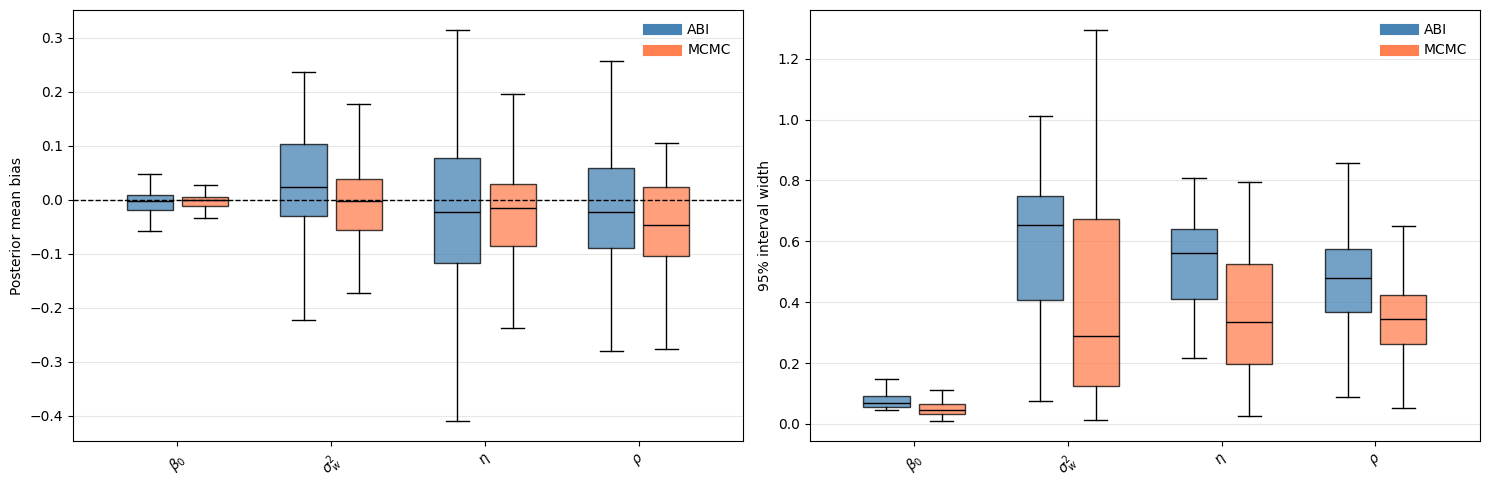

In [11]:
interval_df = param_all.copy()
interval_df["interval_width_95"] = interval_df["upper_95"] - interval_df["lower_95"]

def add_grouped_boxplots(ax, value_col, ylabel):
    colors = {"ABI": ABI_COLOR, "MCMC": MCMC_COLOR}
    offsets = {"ABI": -0.18, "MCMC": 0.18}
    data = []
    positions = []
    box_colors = []
    for idx, parameter in enumerate(param_order):
        for method in ["ABI", "MCMC"]:
            vals = interval_df.loc[(interval_df["parameter"] == parameter) & (interval_df["method"] == method), value_col].dropna().to_numpy()
            if vals.size == 0:
                vals = np.array([np.nan])
            data.append(vals)
            positions.append(idx + offsets[method])
            box_colors.append(colors[method])
    bp = ax.boxplot(data, positions=positions, widths=0.30, patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for median in bp["medians"]:
        median.set_color(REFERENCE_COLOR)
    ax.set_xticks(range(len(param_order)))
    ax.set_xticklabels([PARAM_DISPLAY_MAP[p] for p in param_order], rotation=45)
    ax.set_ylabel(ylabel)
    handles = [plt.Line2D([0], [0], color=colors[m], lw=8) for m in ["ABI", "MCMC"]]
    ax.legend(handles, ["ABI", "MCMC"], frameon=False)
    apply_sim_more_detailed_theme(ax, grid_axis="y")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
add_grouped_boxplots(axes[0], "bias_mean", "Posterior mean bias")
axes[0].axhline(0.0, linestyle="--", color=REFERENCE_COLOR, linewidth=1)

add_grouped_boxplots(axes[1], "interval_width_95", "95% interval width")

plt.tight_layout()
save_comparison_figure(fig, "parameter_bias_interval_boxplots.png")
plt.show()


## 4. Boundary metrics against truth

In [12]:
edge_metric_method_summary = summarize_edge_metrics(edge_metrics_all)

display(edge_metric_method_summary)
display(edge_metrics_all.head())


,method,auroc_mean,auroc_median,average_precision_mean,average_precision_median,brier_mean,brier_median,sensitivity_mpm_mean,sensitivity_mpm_median,specificity_mpm_mean,specificity_mpm_median,posterior_boundary_count_mpm_mean,posterior_boundary_count_mpm_median,true_boundary_count_mean,true_boundary_count_median,boundary_count_mean_draws_mean,boundary_count_mean_draws_median,boundary_count_truth_in_95_mean,boundary_count_truth_in_95_median
0,ABI,1.0,1.0,1.0,1.0,0.064677,0.050850,0.685863,0.838440,0.961993,1.0,94.48,62.0,104.14,68.0,98.830308,71.04940,0.97,1.0
1,MCMC,1.0,1.0,1.0,1.0,0.040825,0.027763,0.764112,0.928571,0.977038,1.0,94.47,66.5,104.14,68.0,95.762146,63.99745,0.97,1.0


,dataset_id,edge_count,true_boundary_count,posterior_boundary_count_mpm,auroc,average_precision,brier,sensitivity_mpm,specificity_mpm,boundary_count_mean_draws,boundary_count_lower_95,boundary_count_upper_95,boundary_count_truth_in_95,method
0,dataset_0000,161,33,0,1.0,1.0,0.111054,0.000000,1.000000,12.8478,0.0,75.000,1,ABI
1,dataset_0001,242,121,76,1.0,1.0,0.136002,0.628099,1.000000,71.0112,0.0,117.000,0,ABI
2,dataset_0002,490,8,4,1.0,1.0,0.017620,0.500000,1.000000,30.4936,0.0,157.000,1,ABI
3,dataset_0003,381,158,163,1.0,1.0,0.016915,1.000000,0.977578,160.9913,103.0,189.000,1,ABI
4,dataset_0004,638,148,39,1.0,1.0,0.105438,0.263514,1.000000,55.3416,0.0,194.025,1,ABI


Saved figure to: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC\datasets\benchmark_bank_seed123_n100\comparison_abi_vs_mcmc\plots\boundary_metric_bars.png


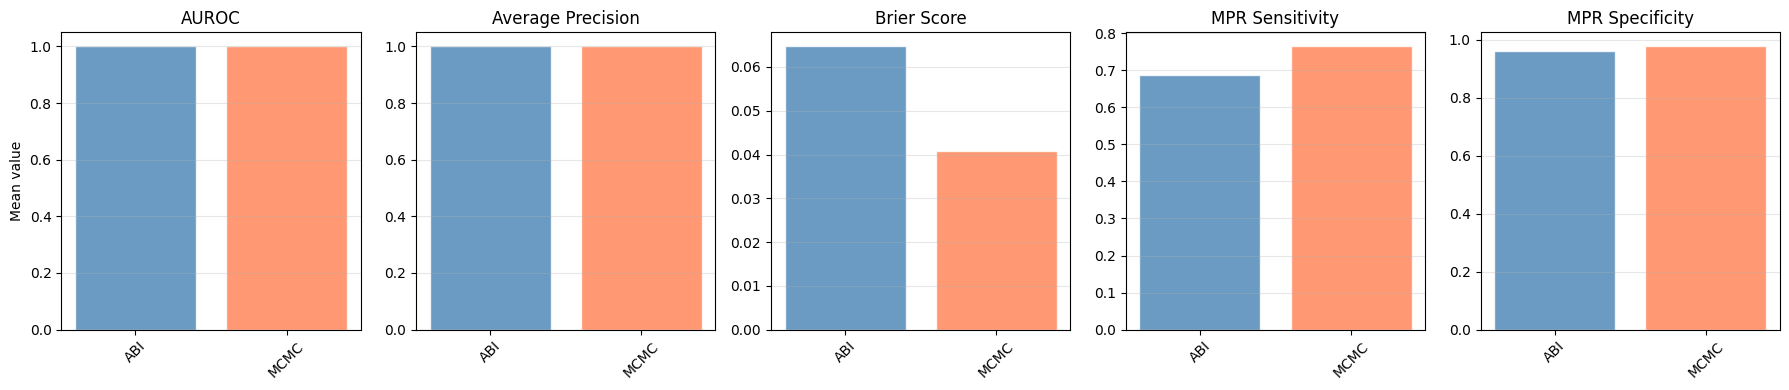

In [18]:
metric_names = ["auroc", "average_precision", "brier", "sensitivity_mpm", "specificity_mpm"]
metric_titles = {
    "auroc": "AUROC",
    "average_precision": "Average Precision",
    "brier": "Brier Score",
    "sensitivity_mpm": "MPR Sensitivity",
    "specificity_mpm": "MPR Specificity",
}
fig, axes = plt.subplots(1, len(metric_names), figsize=(18, 4))
for idx, (ax, metric) in enumerate(zip(axes, metric_names)):
    plot_df = edge_metrics_all.groupby("method", as_index=False)[metric].mean()
    ax.bar(plot_df["method"], plot_df[metric], color=[ABI_COLOR, MCMC_COLOR], alpha=0.8, edgecolor="white")
    ax.set_title(metric_titles.get(metric, metric))
    if idx == 0:
        ax.set_ylabel("Mean value")
    ax.tick_params(axis="x", rotation=45)
    apply_sim_more_detailed_theme(ax, grid_axis="y")
plt.tight_layout()
save_comparison_figure(fig, "boundary_metric_bars.png")
plt.show()


## 5. Edge-level ABI versus MCMC agreement

In [14]:
edge_pairs, edge_agreement_by_dataset = load_edge_probability_pairs(ABI_RESULTS_DIR, MCMC_RESULTS_DIR)
edge_agreement_summary = summarize_edge_agreement(edge_agreement_by_dataset)

display(edge_agreement_summary)
display(edge_agreement_by_dataset.head())


,metric,mean,median,sd,min,max
0,boundary_prob_corr,0.919963,0.956723,0.099306,0.455632,0.999350
1,boundary_prob_mae,0.066164,0.054316,0.046181,0.005188,0.218175
2,abi_selected,94.480000,62.000000,97.194118,0.000000,362.000000
3,mcmc_selected,94.470000,66.500000,99.214944,0.000000,427.000000
4,shared_selected,79.100000,42.000000,91.745311,0.000000,362.000000
5,jaccard_selected,0.592561,0.690445,0.338398,0.000000,1.000000
6,abi_in_mcmc_pct,79.631703,100.000000,34.242502,0.000000,100.000000
7,mcmc_in_abi_pct,77.729196,91.996933,29.221887,0.000000,100.000000


,dataset_id,edge_count,truth_boundary_count,boundary_prob_corr,boundary_prob_mae,abi_selected,mcmc_selected,shared_selected,jaccard_selected,abi_in_mcmc_pct,mcmc_in_abi_pct
0,dataset_0000,161,33,0.987733,0.011132,0,0,0,NaN,NaN,NaN
1,dataset_0001,242,121,0.957116,0.103290,76,99,76,0.767677,100.000000,76.767677
2,dataset_0002,490,8,0.986916,0.025960,4,17,4,0.235294,100.000000,23.529412
3,dataset_0003,381,158,0.890136,0.110835,163,117,117,0.717791,71.779141,100.000000
4,dataset_0004,638,148,0.973400,0.084472,39,87,39,0.448276,100.000000,44.827586


Saved figure to: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC\datasets\benchmark_bank_seed123_n100\comparison_abi_vs_mcmc\plots\edge_agreement_dataset_0000.png


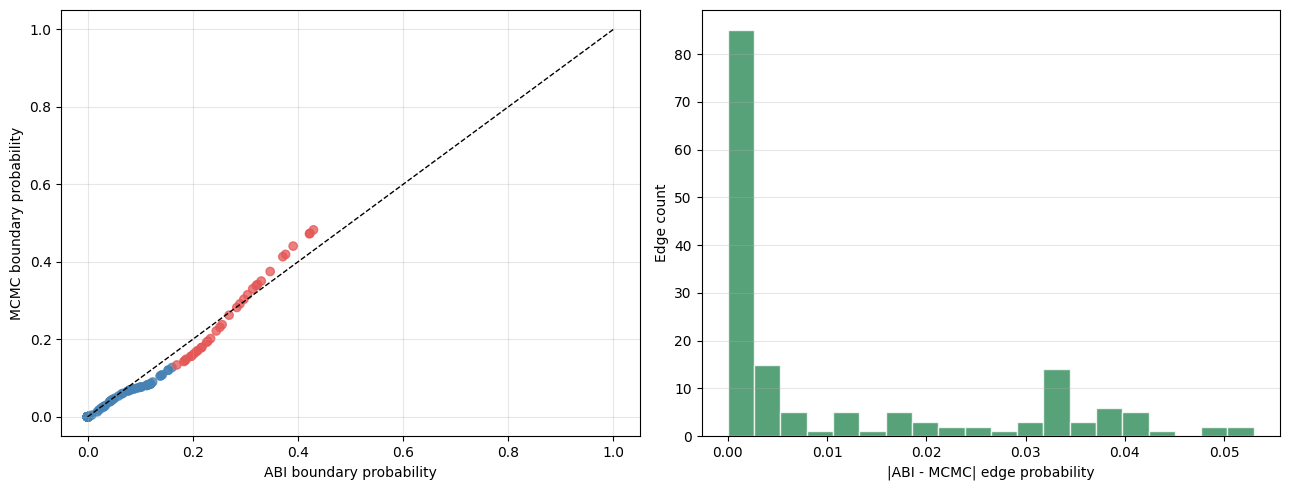

In [15]:
selected_dataset_id = EDGE_PLOT_DATASET_ID or edge_agreement_by_dataset.iloc[0]["dataset_id"]
plot_df = edge_pairs[edge_pairs["dataset_id"] == selected_dataset_id].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = np.where(plot_df["boundary_true"] == 1, TRUE_BOUNDARY_COLOR, NONBOUNDARY_COLOR) if "boundary_true" in plot_df.columns else NONBOUNDARY_COLOR
ax.scatter(plot_df["boundary_prob_abi"], plot_df["boundary_prob_mcmc"], c=colors, alpha=0.75)
ax.plot([0, 1], [0, 1], linestyle="--", color=REFERENCE_COLOR, linewidth=1)
ax.set_xlabel("ABI boundary probability")
ax.set_ylabel("MCMC boundary probability")
apply_sim_more_detailed_theme(ax)

ax = axes[1]
ax.hist(plot_df["abs_prob_diff"], bins=20, color=AGREEMENT_COLOR, alpha=0.8, edgecolor="white")
ax.set_xlabel("|ABI - MCMC| edge probability")
ax.set_ylabel("Edge count")
apply_sim_more_detailed_theme(ax, grid_axis="y")

plt.tight_layout()
save_comparison_figure(fig, f"edge_agreement_{selected_dataset_id}.png")
plt.show()


## 6. Export comparison tables

In [16]:
comparison_tables = {
    "runtime_comparison_by_dataset.csv": runtime_comparison,
    "runtime_summary.csv": runtime_summary,
    "break_even_summary.csv": break_even_summary,
    "break_even_scenarios.csv": break_even_scenarios,
    "parameter_method_summary.csv": parameter_method_summary,
    "parameter_pairwise_by_dataset.csv": parameter_pairwise,
    "parameter_agreement_summary.csv": parameter_agreement_summary,
    "edge_metric_method_summary.csv": edge_metric_method_summary,
    "edge_agreement_by_dataset.csv": edge_agreement_by_dataset,
    "edge_agreement_summary.csv": edge_agreement_summary,
}

if EXPORT_TABLES:
    COMPARISON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for filename, df in comparison_tables.items():
        df.to_csv(COMPARISON_OUTPUT_DIR / filename, index=False)
    print(f"Saved comparison tables to: {COMPARISON_OUTPUT_DIR}")
else:
    print("EXPORT_TABLES is False; no files were written.")


Saved comparison tables to: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\ABI_vs_MCMC\datasets\benchmark_bank_seed123_n100\comparison_abi_vs_mcmc
